Loading pre-trained YOLOv8 Segmentation model...

Running segmentation inference on 10 images...

0: 640x640 2 birds, 210.7ms
1: 640x640 1 bird, 210.7ms
2: 640x640 3 birds, 1 frisbee, 210.7ms
3: 640x640 1 bird, 210.7ms
4: 640x640 1 bird, 210.7ms
5: 640x640 2 birds, 210.7ms
6: 640x640 1 bird, 210.7ms
7: 640x640 1 bird, 1 giraffe, 210.7ms
8: 640x640 1 person, 1 horse, 210.7ms
9: 640x640 1 bird, 1 giraffe, 210.7ms
Speed: 13.5ms preprocess, 210.7ms inference, 10.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\muham\runs\segment\predict-3

Displaying the 10 pixel-perfect segmentation masks:


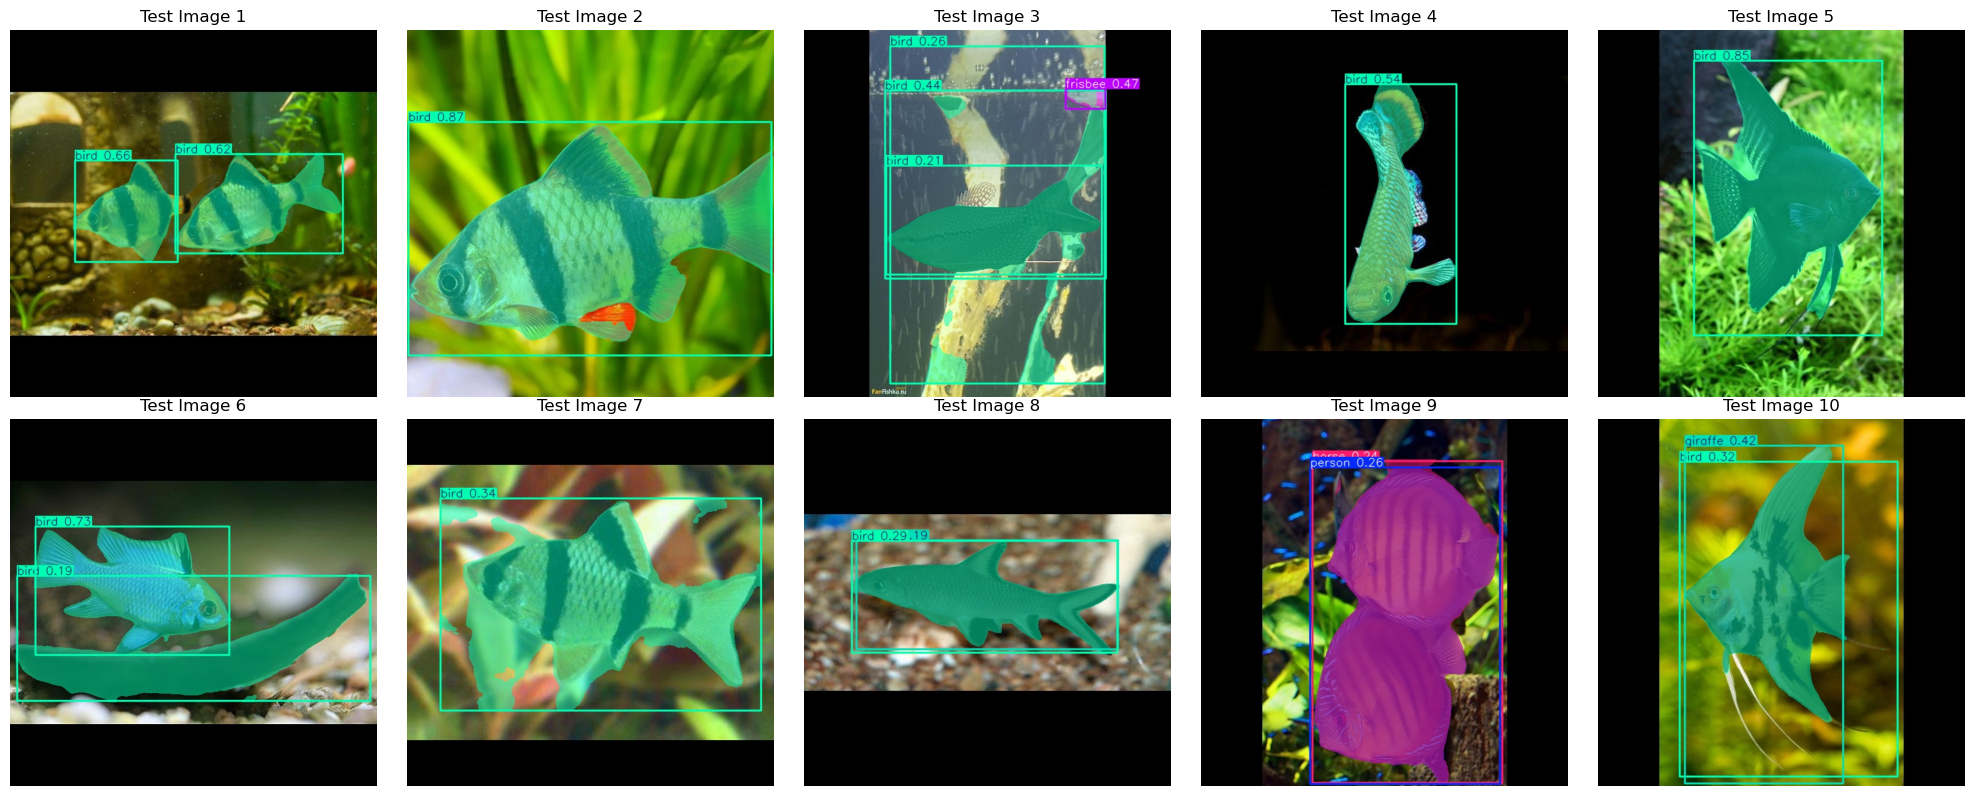

In [1]:
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

# 1. LOAD THE PRE-TRAINED SEGMENTATION MODEL
print("Loading pre-trained YOLOv8 Segmentation model...")
model_seg = YOLO('yolov8n-seg.pt') 

# 2. FIND 10 TEST IMAGES FROM THE DATASET
# Jupyter'in çalıştığı klasördeki test resimlerini otomatik buluyoruz
test_folder = glob.glob(os.path.join(os.getcwd(), "**", "OD-of-Aquarium-Fishes--*", "test", "images"), recursive=True)

if test_folder:
    # Klasör bulunduysa ilk 10 resmi al
    test_images = glob.glob(os.path.join(test_folder[0], "*.jpg"))[:10]
else:
    # Hata önlemi: Eğer bulamazsa Ultralytics'in örnek resimlerini kullanır
    print("Local test folder not found. Using default URLs.")
    test_images = ['https://ultralytics.com/images/bus.jpg', 'https://ultralytics.com/images/zidane.jpg'] * 5

# 3. RUN INFERENCE ON 10 IMAGES
print(f"\nRunning segmentation inference on {len(test_images)} images...")
# Modelin farklı nesneleri de yakalaması için güven (conf) eşiğini 0.15'e çektik
results = model_seg.predict(source=test_images, save=True, conf=0.15)

# 4. DISPLAY THE RESULTS IN A 2x5 GRID
print("\nDisplaying the 10 pixel-perfect segmentation masks:")
save_dir = results[0].save_dir

plt.figure(figsize=(20, 8))
for i, res in enumerate(results):
    # Kaydedilen resmin adını ve yolunu buluyoruz
    img_name = os.path.basename(res.path)
    result_image_path = os.path.join(save_dir, img_name)
    
    # Resmi çizdiriyoruz
    if os.path.exists(result_image_path):
        img = mpimg.imread(result_image_path)
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Test Image {i+1}")

plt.tight_layout()
plt.show()